In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [ ]:
folder_path = "/content/drive/MyDrive/BANGLADESH_RANDOM"

all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

print("Total files:", len(all_files))

dfs = []

for file in all_files:
    path = os.path.join(folder_path, file)
    df = pd.read_csv(path)

    df["source_file"] = file   # 🔥 important
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

print("Initial shape:", full_df.shape)

Total files: 15
Initial shape: (600000, 72)


In [ ]:
embedding_cols = [col for col in full_df.columns if col.startswith("A")]

full_df = full_df[embedding_cols + ["label", "source_file"]]

print("After selection:", full_df.shape)

After selection: (600000, 66)


In [ ]:
before = len(full_df)

full_df = full_df.drop_duplicates().reset_index(drop=True)

after = len(full_df)

print("Removed duplicates:", before - after)
print("Final dataset size:", after)

Removed duplicates: 122350
Final dataset size: 477650


In [ ]:
np.random.seed(42)

unique_files = full_df["source_file"].unique()
np.random.shuffle(unique_files)

train_files = unique_files[:11]
val_files   = unique_files[11:]

print("Train files:", train_files)
print("Val files:", val_files)

Train files: ['BGD_52_81_balanced_random_40k.csv' 'BGD_43_99_balanced_random_40k.csv'
 'BGD_67_19_balanced_random_40k.csv' 'BGD_50_83_balanced_random_40k.csv'
 'BGD_64_23_balanced_random_40k.csv' 'BGD_54_69_balanced_random_40k.csv'
 'BGD_56_68_balanced_random_40k.csv' 'BGD_40_119_balanced_random_40k.csv'
 'BGD_62_23_balanced_random_40k.csv' 'BGD_59_27_balanced_random_40k.csv'
 'BGD_52_67_balanced_random_40k.csv']
Val files: ['BGD_50_67_balanced_random_40k.csv' 'BGD_45_90_balanced_random_40k.csv'
 'BGD_53_80_balanced_random_40k.csv' 'BGD_66_18_balanced_random_40k.csv']


In [ ]:
train_df = full_df[full_df["source_file"].isin(train_files)]
val_df   = full_df[full_df["source_file"].isin(val_files)]

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

Train shape: (353603, 66)
Val shape: (124047, 66)


In [ ]:
train_df.head()

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,A56,A57,A58,A59,A60,A61,A62,A63,label,source_file
0,-0.024606,-0.071111,0.147697,-0.113741,-0.044844,0.179377,-0.001538,0.024606,-0.027128,0.276140,...,0.059116,-0.124567,-0.038447,-0.192910,0.012057,-0.055363,0.010396,0.075356,0,BGD_67_19_balanced_random_40k.csv
1,0.008858,-0.075356,0.051734,0.032541,-0.041584,0.098424,0.141730,-0.003014,0.059116,0.364721,...,-0.071111,0.071111,0.075356,-0.147697,0.027128,-0.071111,0.084214,0.093564,0,BGD_67_19_balanced_random_40k.csv
2,-0.055363,-0.088827,0.098424,-0.027128,0.032541,0.098424,0.027128,0.022207,-0.071111,0.374256,...,0.006151,-0.079723,-0.038447,-0.276140,-0.029773,0.015748,0.051734,0.079723,0,BGD_67_19_balanced_random_40k.csv
3,-0.032541,-0.048228,0.179377,-0.093564,-0.041584,0.166336,-0.006151,0.029773,-0.044844,0.267958,...,-0.013841,-0.119093,-0.075356,-0.206936,0.004983,-0.035433,0.038447,0.088827,0,BGD_67_19_balanced_random_40k.csv
4,-0.008858,-0.038447,0.135886,-0.124567,-0.022207,0.166336,0.019931,0.038447,-0.015748,0.284444,...,0.084214,-0.166336,-0.024606,-0.244152,0.027128,-0.051734,-0.024606,0.108512,0,BGD_67_19_balanced_random_40k.csv


In [ ]:
common = pd.merge(
    train_df.drop(columns=["source_file"]),
    val_df.drop(columns=["source_file"]),
    how="inner"
)

print("Overlap rows:", len(common))

Overlap rows: 0


In [ ]:
X_train = train_df[embedding_cols]
y_train = train_df["label"]

X_val = val_df[embedding_cols]
y_val = val_df["label"]

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

def evaluate_model(name, model, X_train, y_train, X_val, y_val):

    # Probabilities
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_val_prob   = model.predict_proba(X_val)[:, 1]

    # Find best threshold (based on validation)
    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        preds = (y_val_prob > t).astype(int)
        f1 = f1_score(y_val, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    # Final predictions
    y_train_pred = (y_train_prob > best_t).astype(int)
    y_val_pred   = (y_val_prob > best_t).astype(int)

    print(f"\n===== {name} =====")
    print("Best Threshold:", best_t)

    print("\n--- TRAIN ---")
    print(classification_report(y_train, y_train_pred))
    print("ROC-AUC:", roc_auc_score(y_train, y_train_prob))

    print("\n--- VALIDATION ---")
    print(classification_report(y_val, y_val_pred))
    print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

In [ ]:
X_train.head()

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,-0.024606,-0.071111,0.147697,-0.113741,-0.044844,0.179377,-0.001538,0.024606,-0.027128,0.276140,...,0.221453,-0.024606,0.059116,-0.124567,-0.038447,-0.192910,0.012057,-0.055363,0.010396,0.075356
1,0.008858,-0.075356,0.051734,0.032541,-0.041584,0.098424,0.141730,-0.003014,0.059116,0.364721,...,0.147697,-0.098424,-0.071111,0.071111,0.075356,-0.147697,0.027128,-0.071111,0.084214,0.093564
2,-0.055363,-0.088827,0.098424,-0.027128,0.032541,0.098424,0.027128,0.022207,-0.071111,0.374256,...,0.186082,0.008858,0.006151,-0.079723,-0.038447,-0.276140,-0.029773,0.015748,0.051734,0.079723
3,-0.032541,-0.048228,0.179377,-0.093564,-0.041584,0.166336,-0.006151,0.029773,-0.044844,0.267958,...,0.228897,-0.051734,-0.013841,-0.119093,-0.075356,-0.206936,0.004983,-0.035433,0.038447,0.088827
4,-0.008858,-0.038447,0.135886,-0.124567,-0.022207,0.166336,0.019931,0.038447,-0.015748,0.284444,...,0.192910,-0.019931,0.084214,-0.166336,-0.024606,-0.244152,0.027128,-0.051734,-0.024606,0.108512


In [ ]:
from sklearn.linear_model import LogisticRegression
import pickle

lr_model = LogisticRegression(max_iter=1000, n_jobs=-1)
lr_model.fit(X_train, y_train)

with open("lr_model.pkl", "wb") as f:
  pickle.dump(lr_model, f)

evaluate_model("LOGISTIC REGRESSION", lr_model, X_train, y_train, X_val, y_val)


===== LOGISTIC REGRESSION =====
Best Threshold: 0.5000000000000001

--- TRAIN ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87    190155
           1       0.86      0.82      0.84    163448

    accuracy                           0.85    353603
   macro avg       0.86      0.85      0.85    353603
weighted avg       0.85      0.85      0.85    353603

ROC-AUC: 0.93636100957538

--- VALIDATION ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     71401
           1       0.79      0.82      0.80     52646

    accuracy                           0.83    124047
   macro avg       0.82      0.83      0.82    124047
weighted avg       0.83      0.83      0.83    124047

ROC-AUC: 0.9148828400427534


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

evaluate_model("RANDOM FOREST", rf_model, X_train, y_train, X_val, y_val)


===== RANDOM FOREST =====
Best Threshold: 0.45000000000000007

--- TRAIN ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    190155
           1       0.98      0.98      0.98    163448

    accuracy                           0.98    353603
   macro avg       0.98      0.98      0.98    353603
weighted avg       0.98      0.98      0.98    353603

ROC-AUC: 0.9988028397856334

--- VALIDATION ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.84     71401
           1       0.80      0.76      0.78     52646

    accuracy                           0.82    124047
   macro avg       0.81      0.81      0.81    124047
weighted avg       0.82      0.82      0.82    124047

ROC-AUC: 0.8935852698473754


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    gamma=0.5,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

evaluate_model("XGBOOST", xgb_model, X_train, y_train, X_val, y_val)


===== XGBOOST =====
Best Threshold: 0.45000000000000007

--- TRAIN ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96    190155
           1       0.95      0.96      0.96    163448

    accuracy                           0.96    353603
   macro avg       0.96      0.96      0.96    353603
weighted avg       0.96      0.96      0.96    353603

ROC-AUC: 0.9937898302332546

--- VALIDATION ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.85     71401
           1       0.79      0.78      0.79     52646

    accuracy                           0.82    124047
   macro avg       0.82      0.82      0.82    124047
weighted avg       0.82      0.82      0.82    124047

ROC-AUC: 0.906194033992513


In [ ]:
from xgboost import XGBClassifier

xgb_model_v2 = XGBClassifier(
    n_estimators=300,          # ↓ fewer trees
    max_depth=6,               # ↓ less complexity
    learning_rate=0.05,        # ↑ slightly higher
    subsample=0.8,             # more randomness
    colsample_bytree=0.7,      # reduce feature overfit
    gamma=1,                   # stronger split penalty
    min_child_weight=10,       # prevents small noisy splits
    reg_alpha=1,               # L1 regularization ↑
    reg_lambda=2,              # L2 regularization ↑
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_model_v2.fit(X_train, y_train)

y_val_prob_xgb_v2 = xgb_model_v2.predict_proba(X_val)[:, 1]

evaluate_model("XGBOOST (TUNED V2)", xgb_model_v2, X_train, y_train, X_val, y_val)


===== XGBOOST (TUNED V2) =====
Best Threshold: 0.45000000000000007

--- TRAIN ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92    190155
           1       0.90      0.90      0.90    163448

    accuracy                           0.91    353603
   macro avg       0.91      0.91      0.91    353603
weighted avg       0.91      0.91      0.91    353603

ROC-AUC: 0.9750593208025179

--- VALIDATION ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     71401
           1       0.79      0.78      0.79     52646

    accuracy                           0.82    124047
   macro avg       0.82      0.82      0.82    124047
weighted avg       0.82      0.82      0.82    124047

ROC-AUC: 0.9020194410625832


In [ ]:
# Logistic Regression
y_val_prob_lr = lr_model.predict_proba(X_val)[:, 1]

# Random Forest
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# XGBoost
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

In [ ]:
assert 'y_val_prob_lr' in globals(), "Run model cells first"

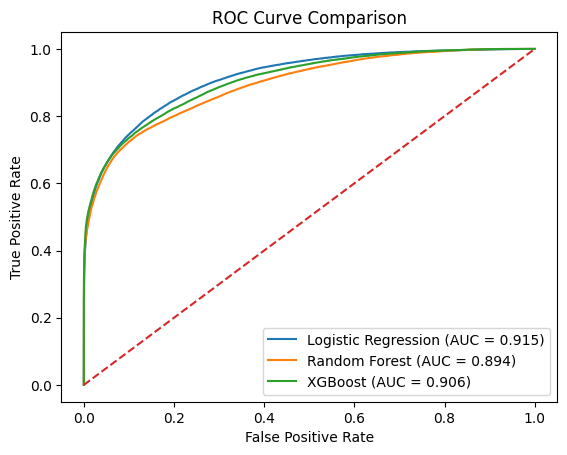

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, y_prob in [
    ("Logistic Regression", y_val_prob_lr),
    ("Random Forest", y_val_prob_rf),
    ("XGBoost", y_val_prob_xgb)
]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

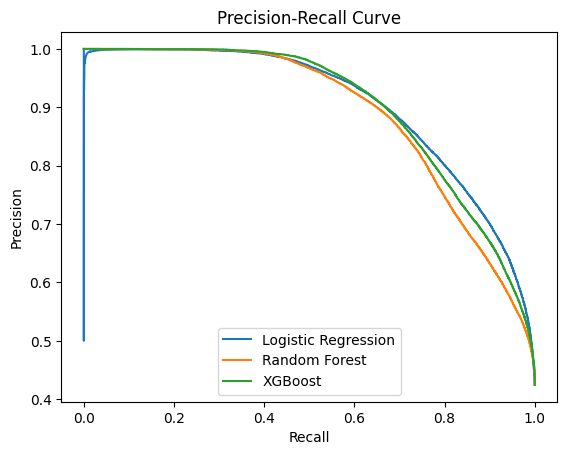

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for name, y_prob in [
    ("Logistic Regression", y_val_prob_lr),
    ("Random Forest", y_val_prob_rf),
    ("XGBoost", y_val_prob_xgb)
]:
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

def find_best_threshold(y_true, y_prob):
    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        preds = (y_prob > t).astype(int)
        f1 = f1_score(y_true, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

In [ ]:
# Probabilities
y_val_prob_lr = lr_model.predict_proba(X_val)[:, 1]
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Thresholds
best_t_lr, _ = find_best_threshold(y_val, y_val_prob_lr)
best_t_xgb, _ = find_best_threshold(y_val, y_val_prob_xgb)

# Predictions
y_val_pred_lr = (y_val_prob_lr > best_t_lr).astype(int)
y_val_pred_xgb = (y_val_prob_xgb > best_t_xgb).astype(int)

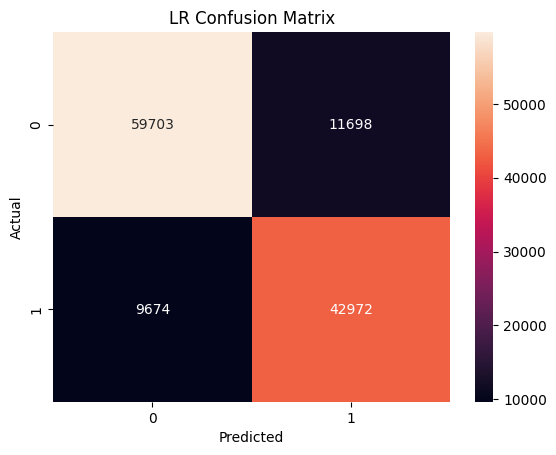

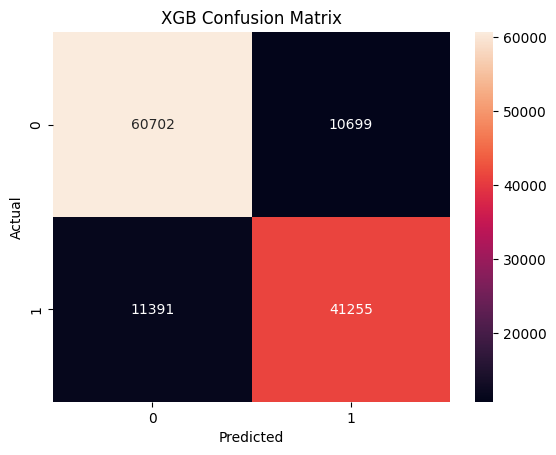

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_val, y_val_pred_lr, "LR Confusion Matrix")
plot_conf_matrix(y_val, y_val_pred_xgb, "XGB Confusion Matrix")

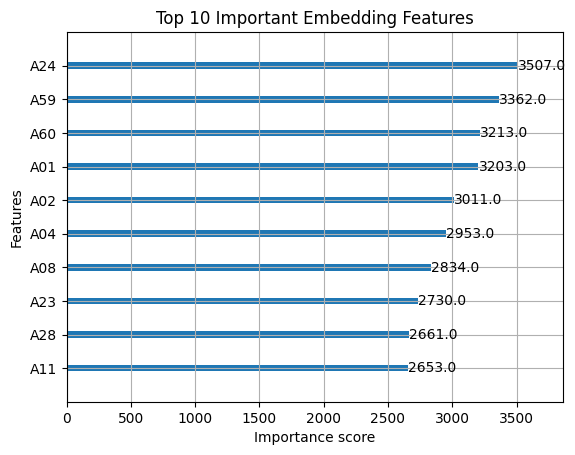

In [ ]:
import xgboost as xgb

xgb.plot_importance(xgb_model, max_num_features=10)
plt.title("Top 10 Important Embedding Features")
plt.show()

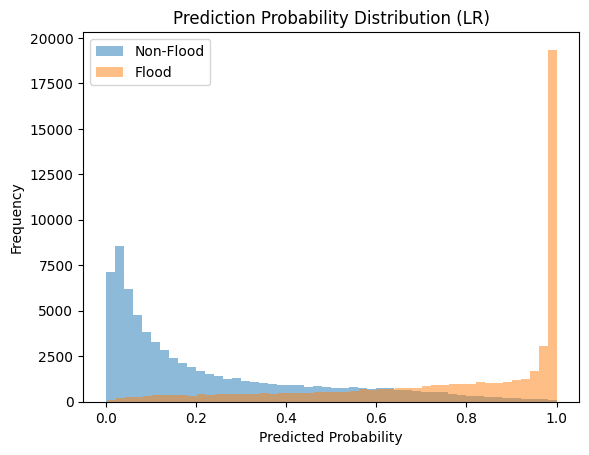

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_val_prob_lr[y_val == 0], bins=50, alpha=0.5, label="Non-Flood")
plt.hist(y_val_prob_lr[y_val == 1], bins=50, alpha=0.5, label="Flood")

plt.title("Prediction Probability Distribution (LR)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

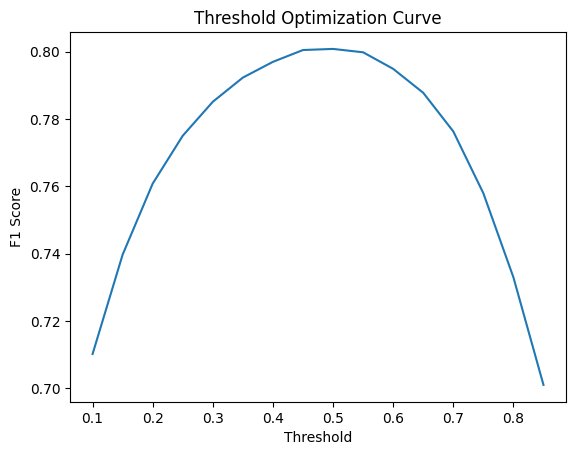

In [ ]:
f1_scores = []

for t in thresholds:
    preds = (y_val_prob_lr > t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization Curve")
plt.show()

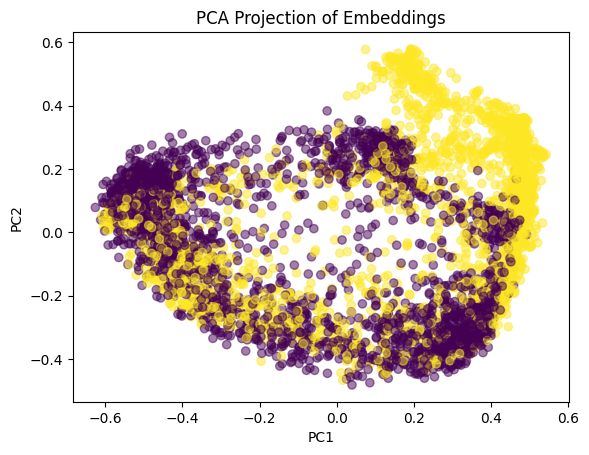

In [ ]:
from sklearn.decomposition import PCA

# Take subset (important for speed)
sample_df = train_df.sample(n=5000, random_state=42)

X_sample = sample_df[embedding_cols]
y_sample = sample_df["label"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, alpha=0.5)
plt.title("PCA Projection of Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
y_val_prob = lr_model.predict_proba(X_val)[:, 1]
best_t, _ = find_best_threshold(y_val, y_val_prob)
y_val_pred = (y_val_prob > best_t).astype(int)

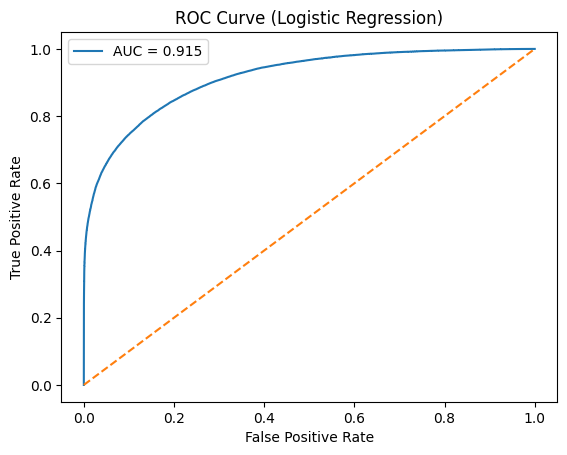

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

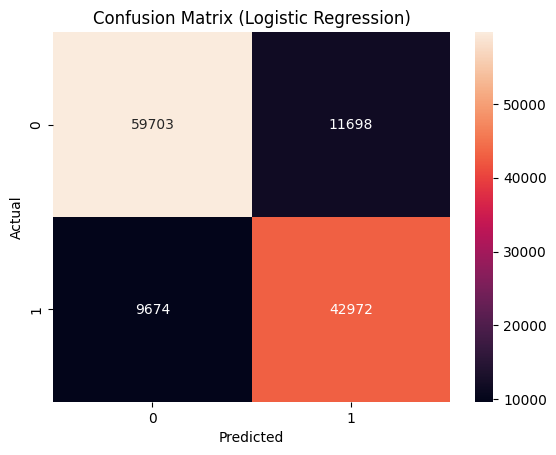

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

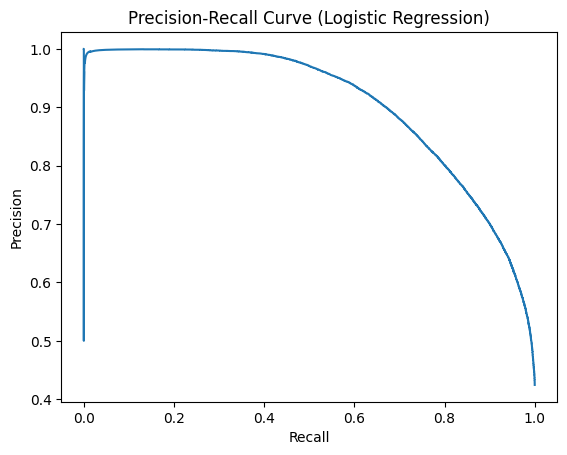

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, y_val_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()

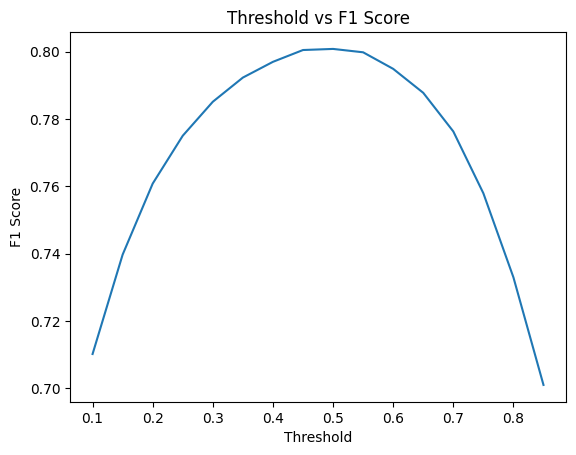

In [ ]:
f1_scores = []

for t in thresholds:
    preds = (y_val_prob > t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

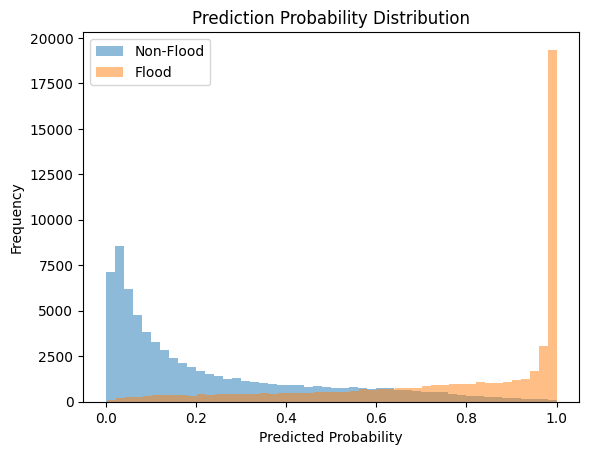

In [ ]:
plt.hist(y_val_prob[y_val == 0], bins=50, alpha=0.5, label="Non-Flood")
plt.hist(y_val_prob[y_val == 1], bins=50, alpha=0.5, label="Flood")

plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

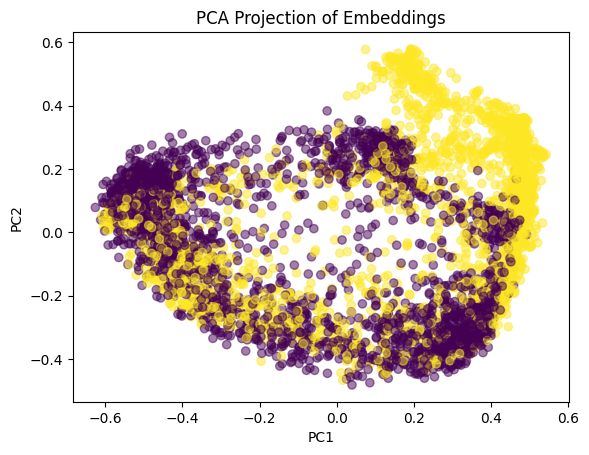

In [ ]:
from sklearn.decomposition import PCA

sample_df = train_df.sample(n=5000, random_state=42)

X_sample = sample_df[embedding_cols]
y_sample = sample_df["label"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, alpha=0.5)
plt.title("PCA Projection of Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ---- 1. Load CSV ----
df = pd.read_csv("/content/BGD_67_19.csv")



In [ ]:
df.head()

,lat,lon,label
0,26.544212,92.298583,0
1,26.544095,92.312839,1
2,26.544505,92.300281,0
3,26.544534,92.290621,1
4,26.544592,92.294983,0


In [ ]:
# ---- 2. Separate features & target ----
# ⚠️ change 'target' to your actual column name
X_test = df.drop(columns=["target"])
y_test = df["target"]

# ---- 3. Load model ----
with open("lr_model.pkl", "rb") as f:
    model = pickle.load(f)

# ---- 4. (If used) Load scaler ----
# with open("scaler.pkl", "rb") as f:
#     scaler = pickle.load(f)
# X_test = scaler.transform(X_test)

# ---- 5. Predict ----
y_pred = model.predict(X_test)

# ---- 6. Metrics ----
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd

# Read CSV file
df = pd.read_csv("/content/BGD_50_67_balanced_random_40k.csv")

# Print first 5 rows
print(df.columns)

Index(['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07',
       'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17',
       'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27',
       'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37',
       'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47',
       'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57',
       'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'label', 'lat', 'latitude',
       'lon', 'longitude', '.geo'],
      dtype='object')


In [ ]:
# ============================================
# WATER/FLOOD PREDICTION MAP
# USING LOGISTIC REGRESSION MODEL
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# ============================================
# 1. LOAD MODEL
# ============================================

with open("lr_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model Loaded Successfully")

# ============================================
# 2. LOAD CSV
# ============================================

csv_path = "BGD_50_67_balanced_random_40k.csv"

df = pd.read_csv(csv_path)

print("CSV Loaded")
print("CSV Shape:", df.shape)

# ============================================
# 3. INPUT FEATURES
# ============================================

# Only columns starting with A
# are input embeddings

embedding_cols = [col for col in df.columns if col.startswith("A")]

print("\nNumber of Embedding Columns:", len(embedding_cols))

print("\nEmbedding Columns:")
print(embedding_cols)

# Feature matrix
X = df[embedding_cols]

# Target column
y = df["label"]

print("\nInput Shape:", X.shape)

# ============================================
# 4. MODEL PREDICTION
# ============================================

predictions = model.predict(X)

print("\nPrediction Completed")

print("Unique Predictions:", np.unique(predictions))

# ============================================
# 5. CREATE SPATIAL MAP
# ============================================

lat = df["lat"].values
lon = df["lon"].values

# Normalize coordinates

lat_norm = ((lat - lat.min()) /
            (lat.max() - lat.min()) * 500).astype(int)

lon_norm = ((lon - lon.min()) /
            (lon.max() - lon.min()) * 500).astype(int)

# Empty maps

pred_map = np.full((501, 501), np.nan)
true_map = np.full((501, 501), np.nan)

# Fill maps

for i in range(len(predictions)):

    row = 500 - lat_norm[i]
    col = lon_norm[i]

    pred_map[row, col] = predictions[i]
    true_map[row, col] = y.iloc[i]

# ============================================
# 6. PLOT PREDICTION MAP
# ============================================

plt.figure(figsize=(10,10))

plt.imshow(pred_map, cmap="Blues")

plt.title("Logistic Regression Flood Prediction")

plt.colorbar(label="Prediction")

plt.axis("off")

plt.show()

# ============================================
# 7. PLOT GROUND TRUTH
# ============================================

plt.figure(figsize=(10,10))

plt.imshow(true_map, cmap="Blues")

plt.title("Ground Truth Flood Map")

plt.colorbar(label="Label")

plt.axis("off")

plt.show()

# ============================================
# 8. SAVE PREDICTION MAP
# ============================================

plt.figure(figsize=(10,10))

plt.imshow(pred_map, cmap="Blues")

plt.title("LR Flood Prediction")

plt.axis("off")

save_path = "lr_flood_prediction_map.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("\nSaved:", save_path)

Model Loaded Successfully
CSV Loaded
CSV Shape: (27373, 71)

Number of Embedding Columns: 64

Embedding Columns:
['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63']

Input Shape: (27373, 64)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Model Loaded Successfully
CSV Loaded
CSV Shape: (40000, 71)

Number of Embedding Columns: 64

Prediction Completed
Unique Predictions: [0 1]

MODEL PERFORMANCE
Accuracy : 0.7087
Precision: 0.6484
Recall   : 0.9123
F1 Score : 0.7580

Confusion Matrix:
[[10104  9896]
 [ 1754 18246]]


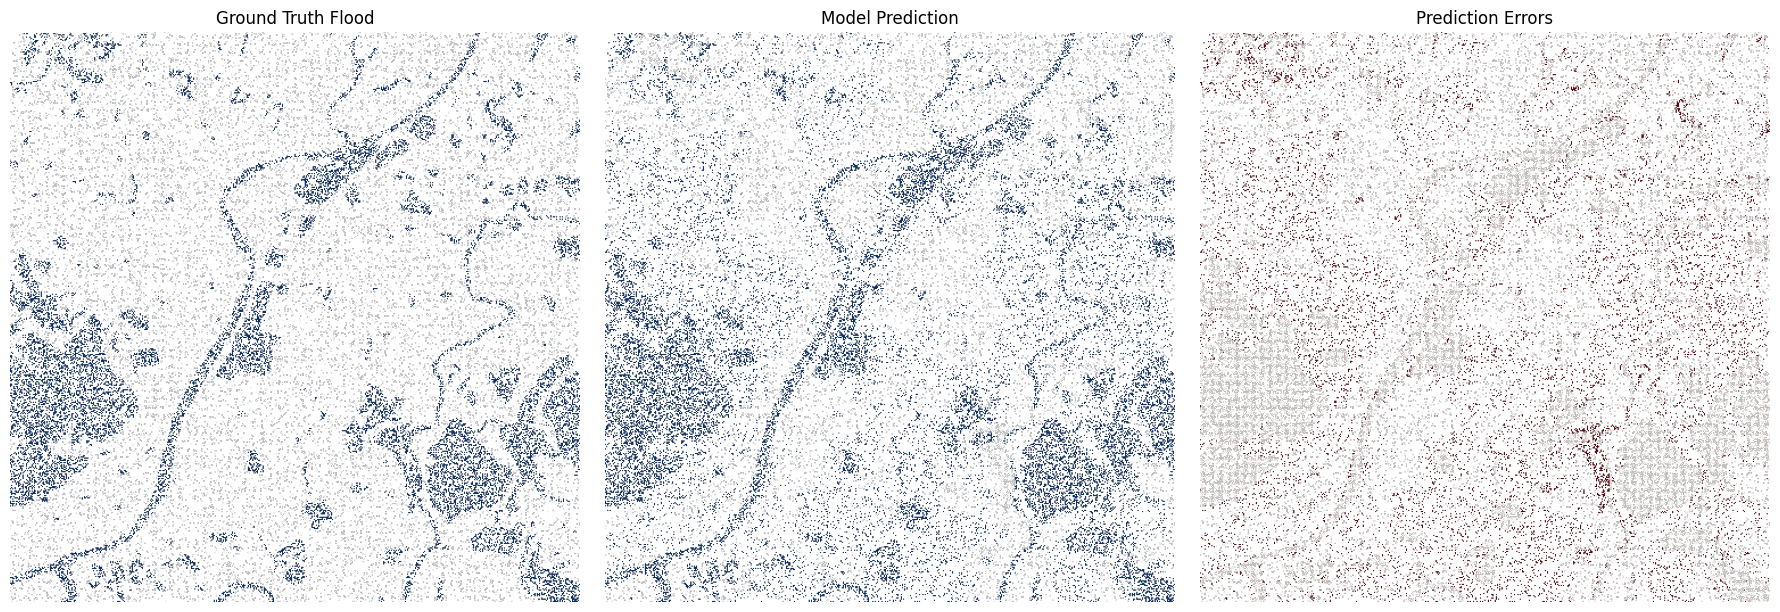


Saved: flood_comparison_graph.png


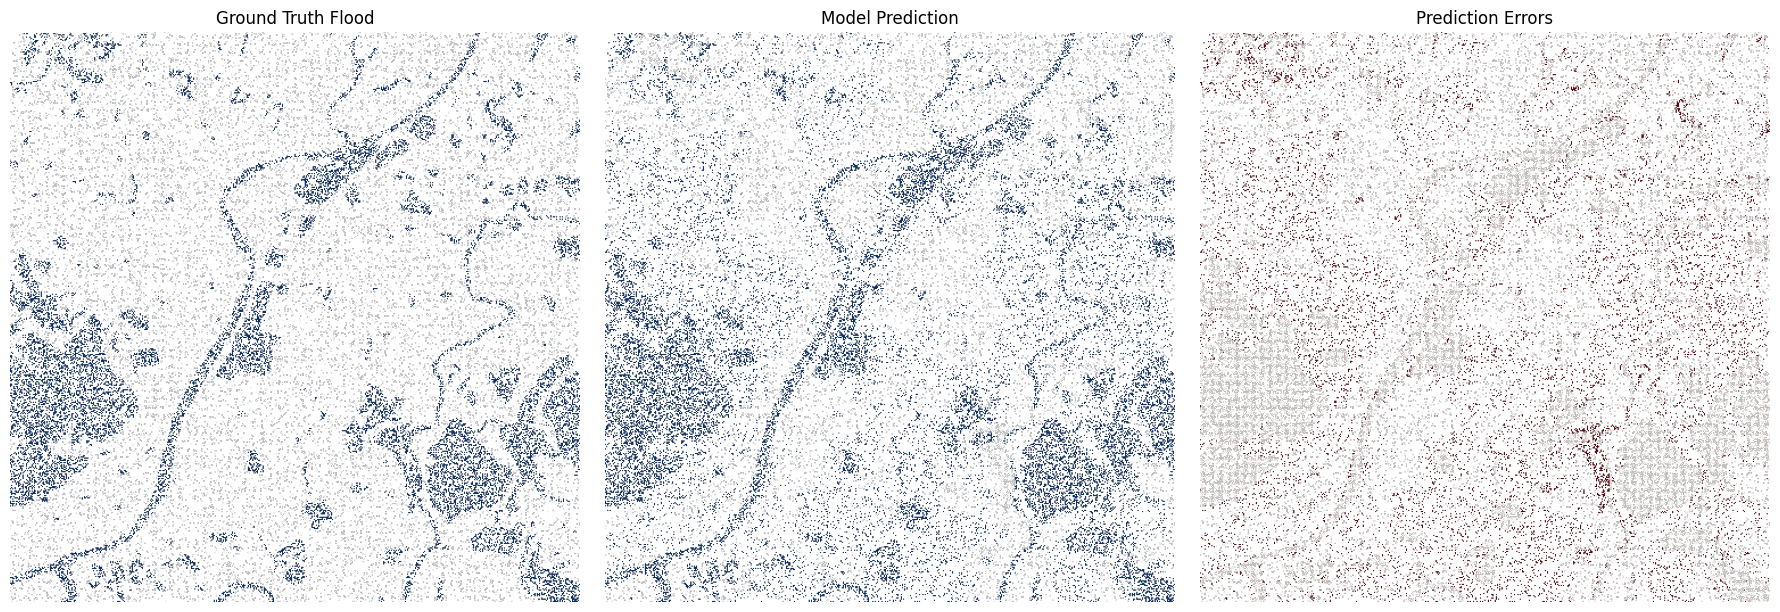

In [ ]:
# ============================================
# FLOOD PREDICTION + COMPARISON VISUALIZATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================
# 1. LOAD MODEL
# ============================================

with open("lr_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model Loaded Successfully")

# ============================================
# 2. LOAD CSV
# ============================================

csv_path = "BGD_50_67_balanced_random_40k.csv"

df = pd.read_csv(csv_path)

print("CSV Loaded")
print("CSV Shape:", df.shape)

# ============================================
# 3. INPUT FEATURES
# ============================================

embedding_cols = [col for col in df.columns if col.startswith("A")]

X = df[embedding_cols]

y = df["label"]

print("\nNumber of Embedding Columns:", len(embedding_cols))

# ============================================
# 4. MODEL PREDICTION
# ============================================

predictions = model.predict(X)

print("\nPrediction Completed")

print("Unique Predictions:", np.unique(predictions))

# ============================================
# 5. EVALUATION METRICS
# ============================================

accuracy  = accuracy_score(y, predictions)
precision = precision_score(y, predictions)
recall    = recall_score(y, predictions)
f1        = f1_score(y, predictions)

cm = confusion_matrix(y, predictions)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

# ============================================
# 6. CREATE SPATIAL MAPS
# ============================================

lat = df["lat"].values
lon = df["lon"].values

# Normalize coordinates

lat_norm = ((lat - lat.min()) /
            (lat.max() - lat.min()) * 500).astype(int)

lon_norm = ((lon - lon.min()) /
            (lon.max() - lon.min()) * 500).astype(int)

# Empty maps

pred_map = np.full((501, 501), np.nan)
true_map = np.full((501, 501), np.nan)

# Fill maps

for i in range(len(predictions)):

    row = 500 - lat_norm[i]
    col = lon_norm[i]

    pred_map[row, col] = predictions[i]
    true_map[row, col] = y.iloc[i]

# ============================================
# 7. COMPARISON GRAPH
# ============================================

plt.figure(figsize=(18,6))

# --------------------------------
# Ground Truth
# --------------------------------
plt.subplot(1,3,1)

plt.imshow(true_map, cmap='Blues')

plt.title("Ground Truth Flood")

plt.axis("off")

# --------------------------------
# Prediction
# --------------------------------
plt.subplot(1,3,2)

plt.imshow(pred_map, cmap='Blues')

plt.title("Model Prediction")

plt.axis("off")

# --------------------------------
# Difference/Error Map
# --------------------------------
difference_map = np.where(
    np.isnan(pred_map),
    np.nan,
    pred_map != true_map
)

plt.subplot(1,3,3)

plt.imshow(difference_map, cmap='Reds')

plt.title("Prediction Errors")

plt.axis("off")

plt.tight_layout()

plt.show()

# ============================================
# 8. SAVE COMPARISON GRAPH
# ============================================

plt.figure(figsize=(18,6))

# Ground Truth
plt.subplot(1,3,1)
plt.imshow(true_map, cmap='Blues')
plt.title("Ground Truth Flood")
plt.axis("off")

# Prediction
plt.subplot(1,3,2)
plt.imshow(pred_map, cmap='Blues')
plt.title("Model Prediction")
plt.axis("off")

# Error Map
plt.subplot(1,3,3)
plt.imshow(difference_map, cmap='Reds')
plt.title("Prediction Errors")
plt.axis("off")

plt.tight_layout()

save_path = "flood_comparison_graph.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("\nSaved:", save_path)